In [1]:
import random
import time

import jax
import jax.numpy as jnp
import numpy as np
from flax.training import checkpoints
from matplotlib import pyplot as plt

from diffusion_linking.circles import generate_circles
from diffusion_linking.diffusion import VariationalDiffusion
from diffusion_linking.schedule import LinearSchedule
from diffusion_linking.smc_clustering import (
    GaussianCluster,
    GaussianMixture,
    SMCClusterer,
    plot_particles_2D,
    resample_optimal,
    resample_stratified,
)
from diffusion_linking.utils import generate_batched_score_func

In [2]:
checkpoint_path = "checkpoints/circles"
rng = jax.random.PRNGKey(1)
schedule = LinearSchedule()
model = VariationalDiffusion(rng, dim=2, depth=6, schedule=schedule)

raw_restored = checkpoints.restore_checkpoint(ckpt_dir=checkpoint_path, target=None)
model.params = {"params": raw_restored["model"]["params"]}
model.compile_net()

Dataset to cluster.

(np.float64(-3.263301658630371),
 np.float64(0.15539531707763674),
 np.float64(-4.083533406257629),
 np.float64(5.0101295709609985))

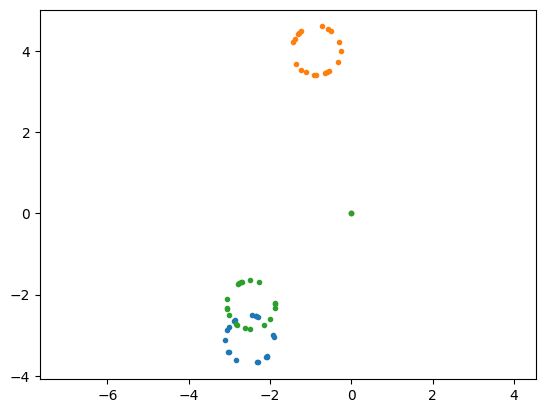

In [3]:
rng = jax.random.PRNGKey(11)
circles_valid, masks_valid = generate_circles(rng, 3, min_points=19, max_points=20, min_radius=0.6, max_radius=0.6)
for cc in circles_valid:
    plt.plot(cc[:, 0], cc[:, 1], "o", markersize=3)
plt.axis("equal")

In [4]:
cluster_data = []
for k, (c, m) in enumerate(zip(circles_valid, masks_valid)):
    for ci, mi in zip(c, m):
        if mi:
            cluster_data.append(ci[None, :])

random.seed(0)
random.shuffle(cluster_data)

In [5]:
rng = jax.random.PRNGKey(1)
circles_valid, masks_valid = generate_circles(rng, 1000, min_points=5, max_points=20, min_radius=0.6, max_radius=0.6)

Sx = jnp.sum(jnp.array(circles_valid), axis=1)
Sxx = jnp.sum(jnp.array(circles_valid) ** 2, axis=1)
n = jnp.sum(jnp.array(masks_valid), axis=1)[:, None]


# estimate prior parameters with moment matching
means = jnp.array([jnp.mean(circles_valid[i][masks_valid[i] > 0], axis=0) for i in range(len(circles_valid))])
variances = jnp.array([jnp.var(circles_valid[i][masks_valid[i] > 0], axis=0) for i in range(len(circles_valid))])
u_sig = jnp.mean(jnp.array(variances), axis=0)
v_sig = jnp.var(jnp.array(variances), axis=0)
a = u_sig**2 / v_sig + 2
b = u_sig * (u_sig**2 / v_sig + 1)

u_mu = jnp.sum(Sx, axis=1) / n
v_mu = jnp.sum(Sxx) / n - jnp.sum(Sx, axis=1) ** 2 / n
mu = jnp.mean(means, axis=0)
lam = jnp.abs(b / a * (jnp.var(means, axis=0) * (2 * a - 2) / 2 / a) ** (-2))

alpha = 1
GMM = GaussianMixture(alpha, a, b, mu, lam)

Cluster the test dataset, plot clusterings with greatest weights.

  5%|█▋                             | 3/55 [00:03<00:27,  1.89it/s, Particles=1]

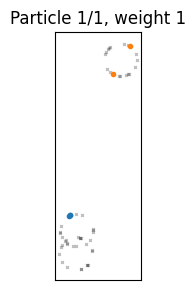

 15%|████▎                         | 8/55 [00:05<00:27,  1.70it/s, Particles=10]

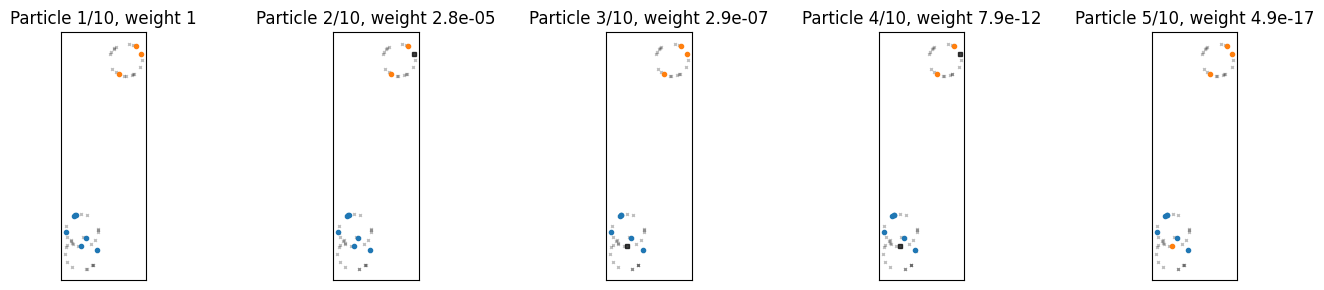

 24%|███████                       | 13/55 [00:07<00:16,  2.48it/s, Particles=3]

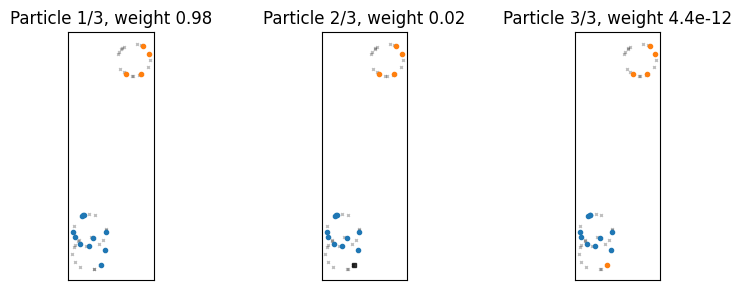

 33%|█████████▊                    | 18/55 [00:09<00:19,  1.88it/s, Particles=7]

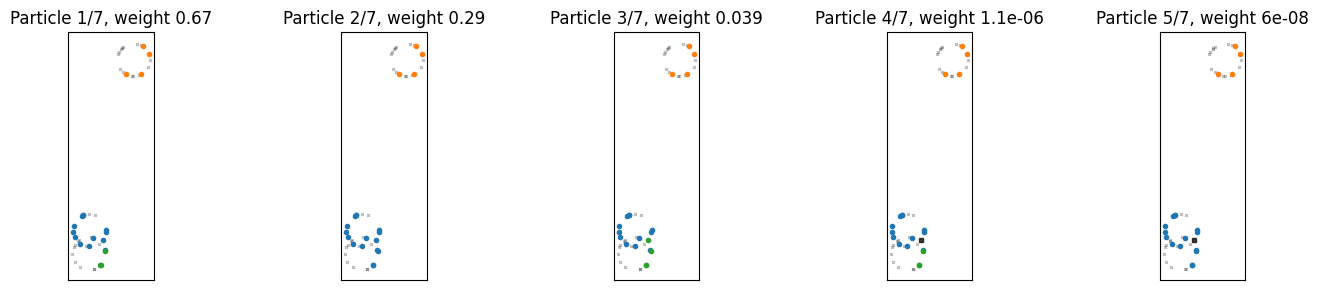

 42%|████████████▌                 | 23/55 [00:14<00:19,  1.63it/s, Particles=2]

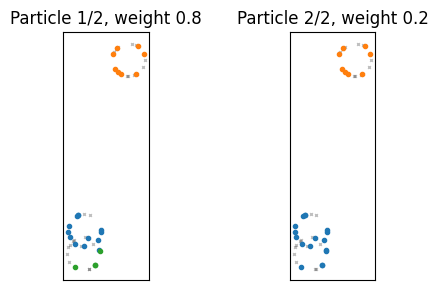

 51%|███████████████▎              | 28/55 [00:16<00:10,  2.49it/s, Particles=1]

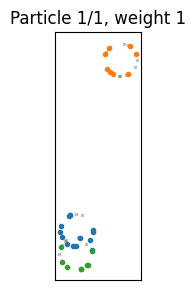

 60%|██████████████████            | 33/55 [00:19<00:09,  2.36it/s, Particles=2]

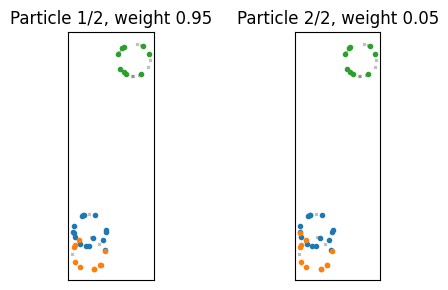

 69%|████████████████████▋         | 38/55 [00:20<00:06,  2.60it/s, Particles=8]

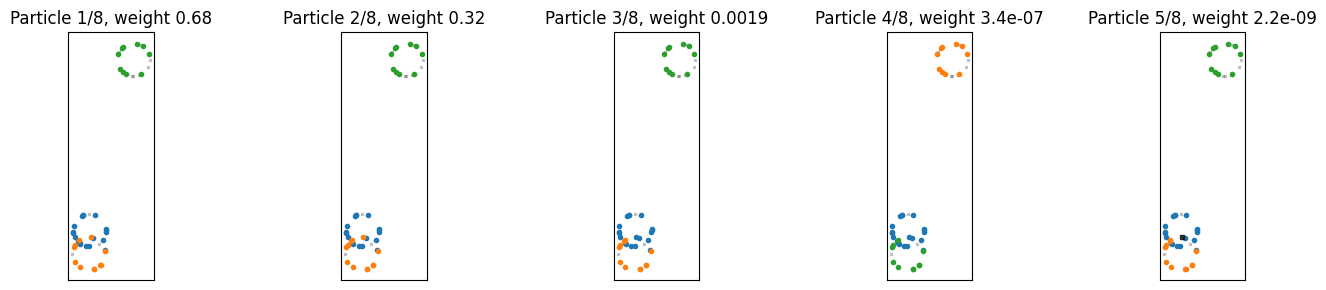

 78%|███████████████████████▍      | 43/55 [00:23<00:05,  2.36it/s, Particles=3]

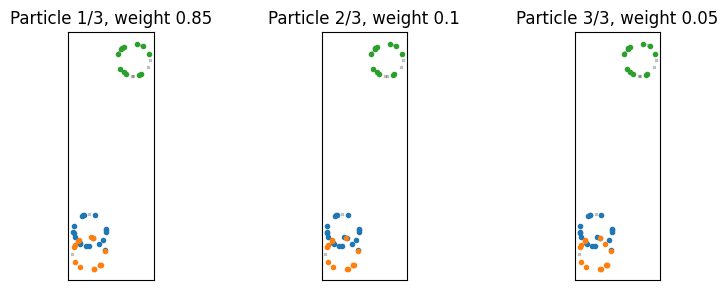

 87%|█████████████████████████▎   | 48/55 [00:25<00:03,  2.00it/s, Particles=12]

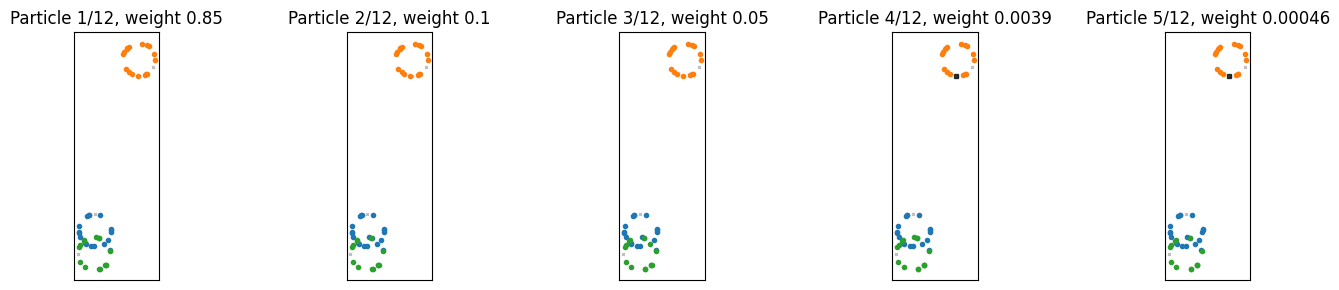

 96%|████████████████████████████▉ | 53/55 [00:28<00:00,  2.84it/s, Particles=2]

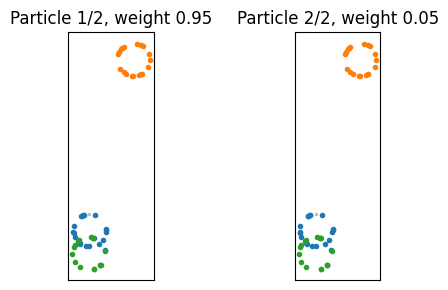

100%|██████████████████████████████| 55/55 [00:28<00:00,  1.95it/s, Particles=8]

In [6]:
num_time_steps = 100


def score_func(rng, data, masks):
    scores, _ = model.log_prob_ode(rng, data, masks, num_time_steps=num_time_steps)
    return scores


batched_score_eval = generate_batched_score_func(score_func)

rng = jax.random.PRNGKey(2)
max_particles = 20
max_evals = 2 * max_particles
clusterer = SMCClusterer(
    data=jnp.array(cluster_data).squeeze(1),
    score_fn=batched_score_eval,
    max_particles=max_particles,
    max_evals=max_evals,
    surrogate=GMM,
    resample_fn=resample_stratified,
    ClusterClass=GaussianCluster,
    callback=plot_particles_2D,
)
clusterer.cluster(rng)

In [7]:
clusterer.summary()

Particle 0, weight 1, 3 clusters, 56 points, [21, 19, 16]
Particle 1, weight 0.00056, 3 clusters, 56 points, [22, 19, 15]
Particle 2, weight 2e-10, 4 clusters, 56 points, [21, 19, 15, 1]
Particle 3, weight 1e-11, 4 clusters, 56 points, [20, 19, 16, 1]
Particle 4, weight 2.2e-23, 3 clusters, 56 points, [20, 19, 17]
Particle 5, weight 1.1e-23, 3 clusters, 56 points, [21, 19, 16]
Particle 6, weight 9.1e-29, 3 clusters, 56 points, [21, 20, 15]
Particle 7, weight 4.8e-30, 3 clusters, 56 points, [20, 20, 16]


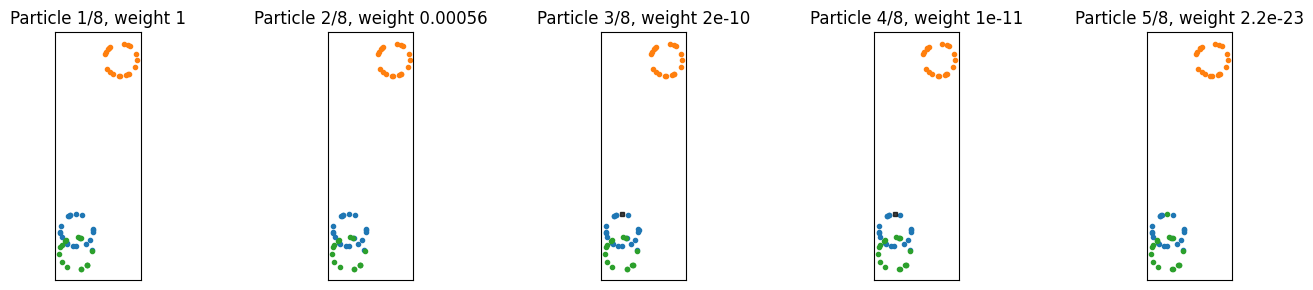

In [8]:
plot_particles_2D(clusterer.state)

Compare to previous clusterer.

iteration 0, linking score: 15.8982
iteration 0, 56 clusters, 57 points, [2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
iteration 1, linking score: 16.6937
iteration 1, 55 clusters, 57 points, [2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
iteration 2, linking score: 15.2687
iteration 2, 54 clusters, 57 points, [2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
iteration 3, linking score: 15.9786
iteration 3, 53 clusters, 57 points, [2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
iteration 4, linking score: 14.9069
iteration 4, 5

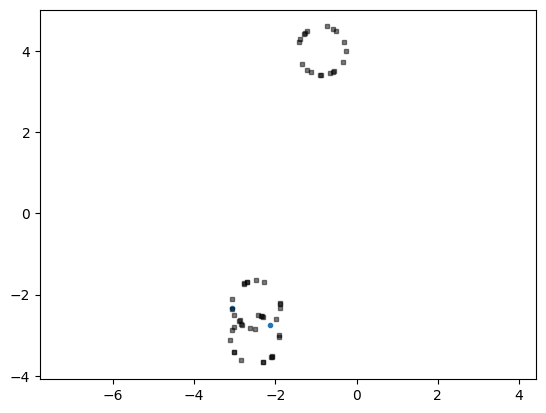

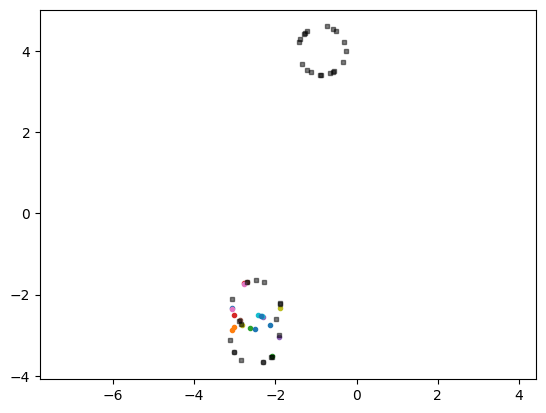

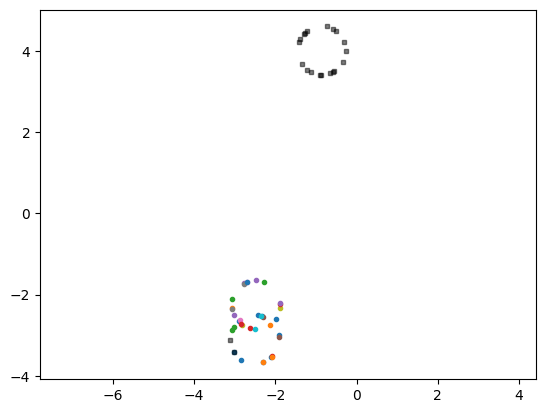

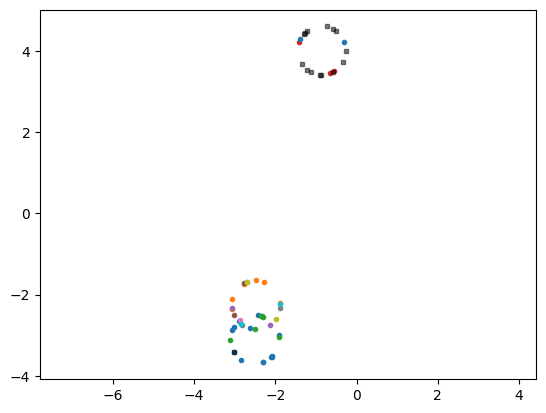

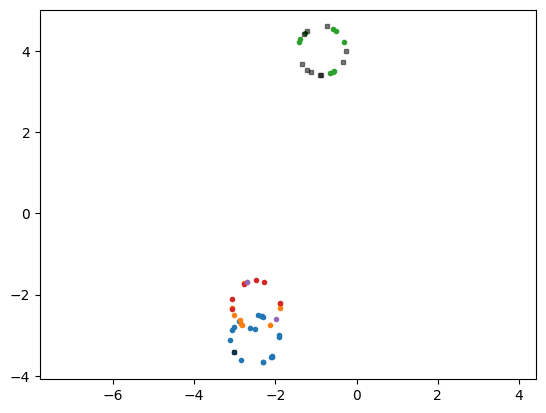

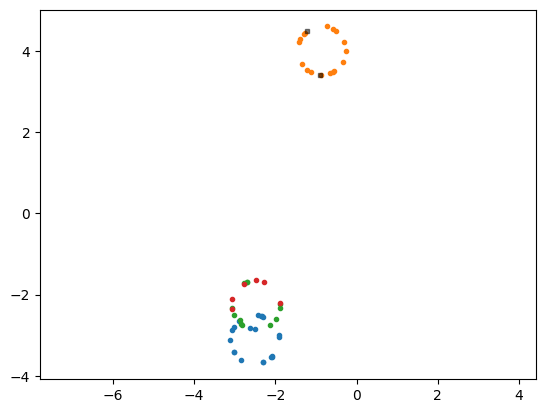

In [9]:
from diffusion_linking.clustering import Clusterer


def plot_callback(clusters, iteration):
    # sort clusters by size
    clusters = sorted(clusters, key=lambda c: c.size, reverse=True)
    if iteration % 10 == 0:
        plt.figure()
        for c in clusters:
            if c.size > 1:
                plt.plot(c.data[:, 0], c.data[:, 1], "o", markersize=3)
            else:
                plt.plot(c.data[:, 0], c.data[:, 1], "ks", markersize=3, alpha=0.5)
        plt.axis("equal")

    print(
        f"iteration {iteration}, {len(clusters)} clusters, {sum([c.size for c in clusters])} points, {[c.size for c in clusters]}"
    )


rng = jax.random.PRNGKey(1)
clusterer2 = Clusterer(
    data=cluster_data, score_fn=score_func, cluster_batch_size=16, link_threshold=0, batch_shape=(16, 16)
)
t = time.time()
clusterer2.cluster(rng, max_iter=100, verbose=True, callback=plot_callback)
print(time.time() - t, "seconds")

iteration 0, 3 clusters, 57 points, [20, 19, 18]


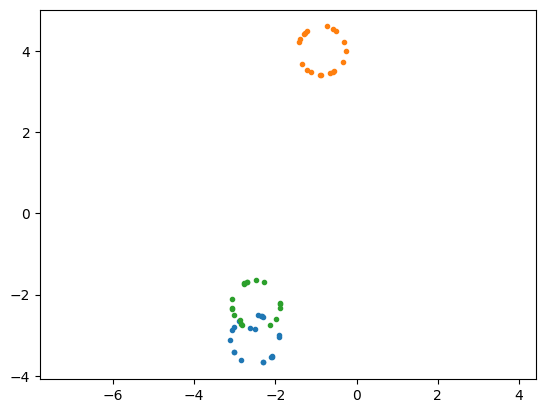

In [10]:
plot_callback(clusterer2.clusters, 0)